# Task
Tell me about this dataset.

Here is all the data you need:
"ds_challenge_v2_1_data.csv"

## Data loading

### Subtask:
Load the dataset "ds_challenge_v2_1_data.csv" into a pandas DataFrame.


**Reasoning**:
Load the dataset into a pandas DataFrame and display the first few rows.



In [ ]:
import pandas as pd
import sqlite3

In [ ]:
try:
    df = pd.read_csv('ds_challenge_v2_1_data.csv')
    display(df.head())
except FileNotFoundError:
    print("Error: 'ds_challenge_v2_1_data.csv' not found.")
except pd.errors.ParserError:
    print("Error: Unable to parse the CSV file.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

/usr/local/lib/python3.11/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")
/usr/local/lib/python3.11/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,id,city_name,signup_os,signup_channel,signup_date,bgc_date,vehicle_added_date,vehicle_make,vehicle_model,vehicle_year,first_completed_date
0,1,Strark,ios web,Paid,1/2/16,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Strark,windows,Paid,1/21/16,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Wrouver,windows,Organic,1/11/16,1/11/16,NaN,NaN,NaN,NaN,NaN
3,4,Berton,android web,Referral,1/29/16,2/3/16,2/3/16,Toyota,Corolla,2016.0,2/3/16
4,5,Strark,android web,Referral,1/10/16,1/25/16,1/26/16,Hyundai,Sonata,2016.0,NaN


## Data exploration

### Subtask:
Explore the DataFrame `df` to identify the column containing vehicle models.


**Reasoning**:
Examine the column names and data types to identify the vehicle model column. Inspect a sample of the data to confirm.



In [ ]:
# Check for columns related to vehicle models
potential_model_columns = [col for col in df.columns if 'model' in col.lower() or 'vehicle' in col.lower()]

# Print the potential model columns
print(f"Potential vehicle model columns: {potential_model_columns}")

# Inspect the first few rows and a random sample of the most likely column
if potential_model_columns:
    most_likely_column = potential_model_columns[0]  # Assume the first one is the most likely
    print(f"\nInspecting column '{most_likely_column}':")
    display(df[most_likely_column].head())
    display(df[most_likely_column].sample(5))
    print(f"\nData type of '{most_likely_column}': {df[most_likely_column].dtype}")


Potential vehicle model columns: ['vehicle_added_date', 'vehicle_make', 'vehicle_model', 'vehicle_year']

Inspecting column 'vehicle_added_date':


,vehicle_added_date
0,NaN
1,NaN
2,NaN
3,2/3/16
4,1/26/16


,vehicle_added_date
16972,2/3/16
46790,NaN
45883,NaN
17291,NaN
38045,1/13/16



Data type of 'vehicle_added_date': object


**Reasoning**:
Based on the output, 'vehicle_model' seems the most likely candidate.  I will further inspect it and other potential columns to confirm.



In [ ]:
# Inspect 'vehicle_model' in more detail
print("\nInspecting column 'vehicle_model':")
display(df['vehicle_model'].head())
display(df['vehicle_model'].sample(5))
print(f"\nData type of 'vehicle_model': {df['vehicle_model'].dtype}")

# Inspect 'vehicle_make' and 'vehicle_year'
print("\nInspecting column 'vehicle_make':")
display(df['vehicle_make'].head())
display(df['vehicle_make'].sample(5))
print(f"\nData type of 'vehicle_make': {df['vehicle_make'].dtype}")

print("\nInspecting column 'vehicle_year':")
display(df['vehicle_year'].head())
display(df['vehicle_year'].sample(5))
print(f"\nData type of 'vehicle_year': {df['vehicle_year'].dtype}")


Inspecting column 'vehicle_model':


,vehicle_model
0,NaN
1,NaN
2,NaN
3,Corolla
4,Sonata


,vehicle_model
40443,NaN
13687,NaN
40653,RDX
37983,CR-V
6378,NaN



Data type of 'vehicle_model': object

Inspecting column 'vehicle_make':


,vehicle_make
0,NaN
1,NaN
2,NaN
3,Toyota
4,Hyundai


,vehicle_make
35639,Ford
41116,Nissan
15629,NaN
25917,Toyota
39513,NaN



Data type of 'vehicle_make': object

Inspecting column 'vehicle_year':


,vehicle_year
0,NaN
1,NaN
2,NaN
3,2016.0
4,2016.0


,vehicle_year
46279,NaN
39580,NaN
22973,NaN
10890,NaN
440,NaN



Data type of 'vehicle_year': float64


## Data wrangling

### Subtask:
Extract the unique vehicle models from the 'vehicle_model' column of the DataFrame `df`.


**Reasoning**:
Extract unique vehicle models from the 'vehicle_model' column, handling potential missing values.



In [ ]:
# Extract unique vehicle models from the 'vehicle_model' column, handling potential missing values.
unique_vehicle_models = [str(x) for x in df['vehicle_model'].unique().tolist()]
unique_vehicle_models.sort()  # Sort the list in-place
print(f"Number of unique vehicle models: {len(unique_vehicle_models)}")
print(f"Unique vehicle models: {unique_vehicle_models}")

Number of unique vehicle models: 369
Unique vehicle models: ['200', '3-Sep', '3-series', '300', '300 H', '4-series Gran Coupe', '4Runner', '5-Sep', '5-series', '500', '500L', '500X', '6-series Gran Coupe', '7-series', 'A3', 'A4', 'A6', 'A8', 'ATS', 'Acadia', 'Accent', 'Accord', 'Accord Hybrid', 'Allroad', 'Altima', 'Altima Hybrid', 'Amanti', 'Armada', 'Aspen', 'Aura', 'Avalanche', 'Avalon', 'Avenger', 'Aveo', 'Aviator', 'Azera', 'Baja', 'Beetle', 'Bicycle', 'Blazer', 'Borrego', 'Bravada', 'C-Class', 'C-Max', 'C-Max Hybrid', 'CC', 'CLA-Class', 'CLK-Class', 'CLS-Class', 'CR-V', 'CT', 'CT Hybrid', 'CTS', 'CX-5', 'CX-7', 'CX-9', 'Cadenza', 'Caliber', 'Camaro', 'Camry', 'Camry Hybrid', 'Camry Solara', 'Canyon', 'Captiva', 'Caravan', 'Cavalier', 'Cayenne', 'Century', 'Charger', 'Cherokee', 'Civic', 'Civic Hybrid', 'Classic', 'Cobalt', 'Colorado', 'Commander', 'Compass', 'Continental', 'Cooper', 'Corolla', 'Countryman', 'Countryman S', 'Crosstour', 'Crown Victoria', 'Cruze', 'Cube', 'DTS', 'D

## Data visualization

### Subtask:
Create a bar chart visualizing the frequency of each unique vehicle model.


**Reasoning**:
Generate the bar chart visualizing the frequency of each unique vehicle model, handling NaN values and limiting the chart to the top 20.



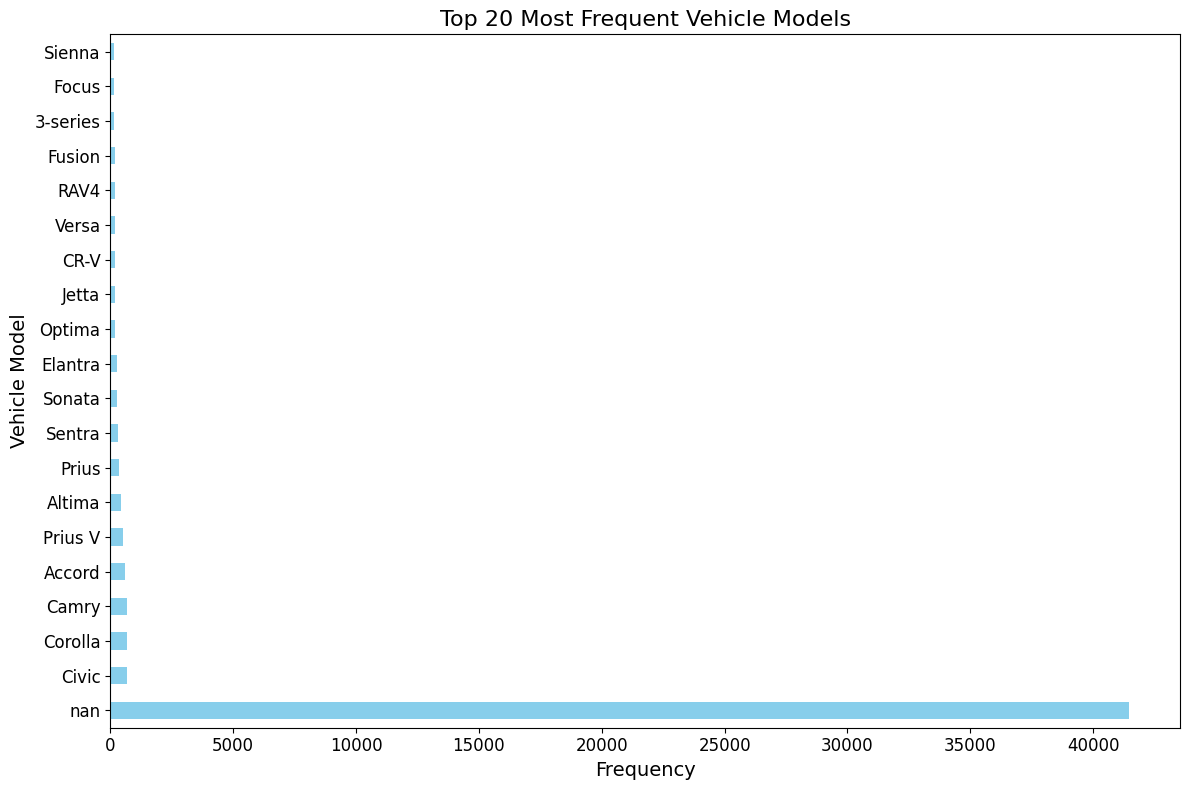

In [ ]:
import matplotlib.pyplot as plt

# Calculate the frequency of each unique vehicle model
vehicle_model_counts = df['vehicle_model'].value_counts(dropna=False)

# Limit the chart to the top 20 most frequent vehicle models
top_20_models = vehicle_model_counts.head(20)

# Create the horizontal bar chart
plt.figure(figsize=(12, 8))
top_20_models.plot(kind='barh', color='skyblue')
plt.title('Top 20 Most Frequent Vehicle Models', fontsize=16)
plt.xlabel('Frequency', fontsize=14)
plt.ylabel('Vehicle Model', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

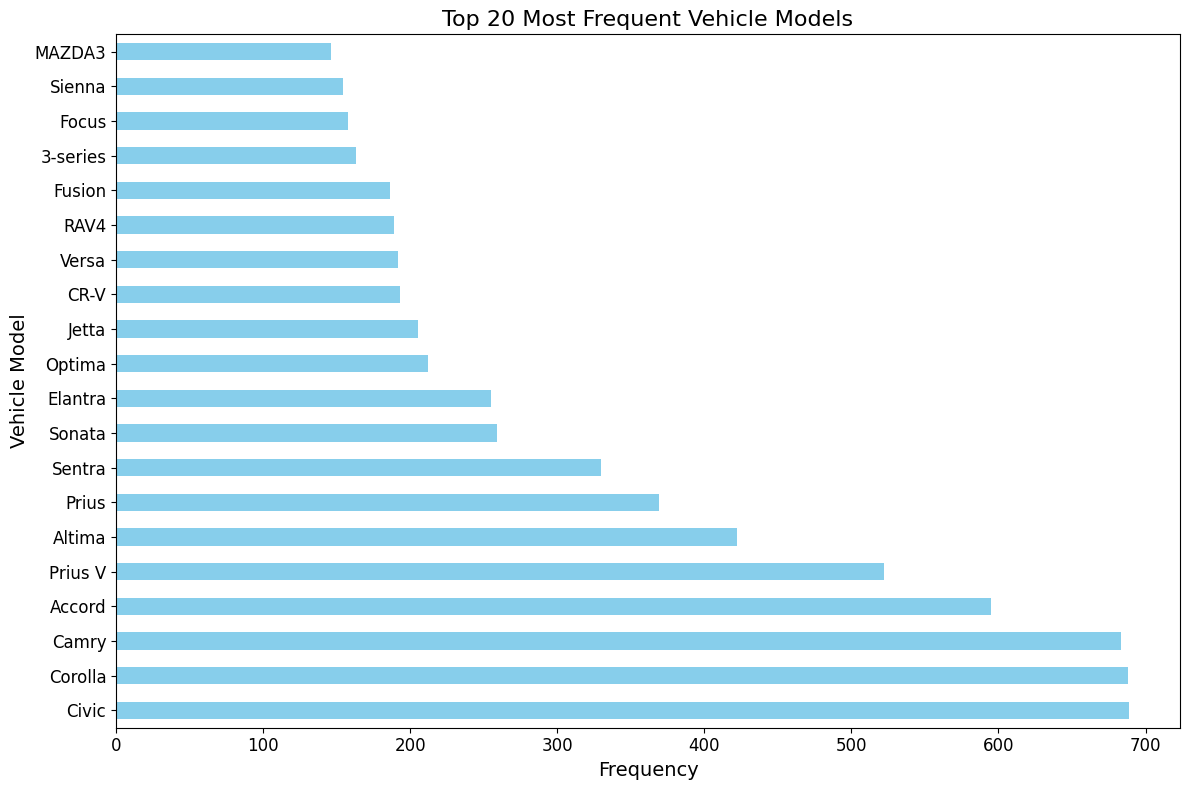

In [ ]:
# Vehicle models without nan
vehicle_model_counts = df['vehicle_model'].value_counts(dropna=True)

# Limit the chart to the top 20 most frequent vehicle models
top_20_models = vehicle_model_counts.head(20)

# Create the horizontal bar chart
plt.figure(figsize=(12, 8))
top_20_models.plot(kind='barh', color='skyblue')
plt.title('Top 20 Most Frequent Vehicle Models', fontsize=16)
plt.xlabel('Frequency', fontsize=14)
plt.ylabel('Vehicle Model', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

## Summary:

### 1. Q&A

* **What is the column containing vehicle model information?**  The `vehicle_model` column.
* **How many unique vehicle models are there?** There are 369 unique vehicle models, including `nan` which represents missing values.


### 2. Data Analysis Key Findings

* **Missing Vehicle Model Data:** The `vehicle_model` column contains missing values (NaN), as evidenced by the inclusion of `nan` in the unique vehicle model list and the frequency counts.  The visualization shows NaN as one of the top 20 most frequent values.
* **Top 20 Vehicle Models:** A bar chart visualizes the frequency distribution of the top 20 most frequent vehicle models.  This provides insight into the most prevalent vehicle models in the dataset.


### 3. Insights or Next Steps

* **Handle Missing Data:** Investigate the reasons behind missing `vehicle_model` data and determine an appropriate strategy to address them.  Options include imputation (filling in missing values) or removal of rows with missing data, depending on the extent and nature of the missingness.
* **Further Model Analysis:** Explore the relationships between vehicle models and other variables (e.g., city, signup date, first completed date) to gain deeper insights into user behavior and preferences.


In [ ]:
# Try specifying a different delimiter or adjusting other parameters
try:
    car_df = pd.read_csv('all-vehicles-model.csv', sep=';',  # Try a different delimiter like semicolon
                          on_bad_lines='skip',  # Skip bad lines
                          # Add other parameters as needed, e.g., quoting, escapechar
                          )
    display(car_df.head())  # Display the first few rows to verify
except FileNotFoundError:
    print("Error: 'all-vehicles-model.csv' not found.")
except pd.errors.ParserError:
    print("Error: Unable to parse the CSV file.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

,Make,Model,Annual Petroleum Consumption For Fuel Type1,Annual Petroleum Consumption For Fuel Type2,Time to charge at 120V,Time to charge at 240V,City Mpg For Fuel Type1,Unrounded City Mpg For Fuel Type1 (2),City Mpg For Fuel Type2,Unrounded City Mpg For Fuel Type2,...,c240Dscr,charge240b,C240B Dscr,Created On,Modified On,Start-Stop,PHEV City,PHEV Highway,PHEV Combined,baseModel
0,Toyota,Corolla,12.396250,0.0,0.0,0.0,23,0.0,0,0.0,...,NaN,0.0,NaN,2013-01-01,2013-01-01,NaN,0,0,0,Corolla
1,Volvo,240,14.875500,0.0,0.0,0.0,18,0.0,0,0.0,...,NaN,0.0,NaN,2013-01-01,2013-01-01,NaN,0,0,0,240
2,Buick,Regal,14.875500,0.0,0.0,0.0,17,0.0,0,0.0,...,NaN,0.0,NaN,2013-01-01,2013-01-01,NaN,0,0,0,Regal
3,Buick,Riviera,14.875500,0.0,0.0,0.0,17,0.0,0,0.0,...,NaN,0.0,NaN,2013-01-01,2013-01-01,NaN,0,0,0,Riviera
4,Dodge,Dynasty,14.167143,0.0,0.0,0.0,18,0.0,0,0.0,...,NaN,0.0,NaN,2013-01-01,2013-01-01,NaN,0,0,0,Dynasty


In [ ]:
unique_vehicle_models = car_df['Model'].unique().tolist()
unique_vehicle_models.sort()  # Sort the list in-place
print(f"Number of unique vehicle models: {len(unique_vehicle_models)}")
print(f"Unique vehicle models: {unique_vehicle_models}")

Number of unique vehicle models: 5064
Unique vehicle models: ['1', '1-Ton Truck 2WD', '100', '100 Wagon', '100 quattro', '100 quattro Wagon', '1000', '124 Spider', '128ci Convertible', '128i', '128i Convertible', '135i', '135i Convertible', '1500 2WD', '1500 4WD', '1500 Classic 2WD', '1500 Classic 4WD', '1500 HFE 2WD', '1500 HO 4WD', '1500 RHO 4WD', '1500 TRX 4WD', '164', '18i', '18i 4DR Wagon', '18i Sportwagon', '190', '190 D 2.2/190 E 2.3', '190D 2.5', '190D 2.5 Turbo', '190E', '190E 2.3', '190E 2.3 MERC BENZ', '190E 2.3-16', '190E 2.6', '1fas 410', '2', '2 BST edition', '2 Dual Motor', '2 Dual Motor (19 Inch Wheels)', '2 Dual Motor (20 Inch Wheels)', '2 Dual Motor Perf Pack', '2 Dual Motor Performance Pack', '2 Single Motor', '2 Single Motor (19 Inch Wheels)', '2 Single Motor (20 Inch Wheels)', '2.2CL/3.0CL', '2.3CL/3.0CL', '2.5TL', '2.5TL/3.2TL', '200', '200 AWD', '200 Convertible', '200 quattro', '200 quattro 20v', '200 quattro 20v Wagon', '200 quattro Wagon', '2000 Sunbird', '200

In [ ]:
vechicle_model = df

In [ ]:
car_df = car_df[['Model', 'Vehicle Size Class']]

In [ ]:
car_df.rename(columns={'Model': 'vehicle_model'}, inplace=True)

In [ ]:
car_df.drop_duplicates(inplace=True)

In [ ]:
car_df.drop_duplicates(subset='vehicle_model', keep='last', inplace=True)

In [ ]:
df_merged = pd.merge(df, car_df, on='vehicle_model', how='left')

In [ ]:
len(df_merged)

54681

In [ ]:
df_merged.columns

In [ ]:
df_merged['Vehicle Size Class'].notnull().sum()


In [ ]:
# Vehicle models without nan
vehicle_model_counts = df['vehicle_model'].value_counts(dropna=True)

# Limit the chart to the top 20 most frequent vehicle models
top_20_models = vehicle_model_counts.head(20)

In [ ]:
# Vehicle models without nan
vehicle_merged = df_merged.dropna()
vehicle_merged = vehicle_merged['Vehicle Size Class'].value_counts(dropna=True)

# Limit the chart to the top 20 most frequent vehicle models
vehicle_merged.head(20)

,count
Vehicle Size Class,
Compact Cars,1847
Midsize Cars,571
Subcompact Cars,566
Large Cars,244
Small Station Wagons,217
Small Sport Utility Vehicle 2WD,155
Sport Utility Vehicle - 4WD,59
Midsize Station Wagons,57
Sport Utility Vehicle - 2WD,41
